# MWE 33 - Synthetic porosity maps from binary and grayscale images

This notebook demonstrates the image-to-continuum porosity-map workflow in
`voids` on a notebook-scale synthetic 3D image. It builds two inputs from the same
PoreSpy `blobs` realization:

- a segmented binary image, where `True` is void and local porosity is a block
  average of the void fraction
- a synthetic grayscale image, where intensity is calibrated to porosity using
  two endpoint grayscale values and a background microporosity floor

Scientific scope and assumptions:

- the input image is synthetic, not scanner-derived micro-CT data
- the grayscale field is generated from the binary image using blur and noise,
  so it is only a toy partial-volume example
- local porosity cells are rectangular block averages on the image grid
- the grayscale calibration assumes a linear relation between intensity and
  porosity between `solid_gray` and `pore_gray`
- the Kozeny-Carman permeability field is an illustrative closure, not a
  calibrated rock property
- exported HDF5 files contain fields and metadata, not a full FEM mesh

See `docs/porosity_maps.md` for the full `block_shape` definition, formulas,
and synthetic verification plan.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import porespy as ps
from scipy import ndimage as ndi

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.image.porosity import (
    load_permeability_map_hdf5,
    load_porosity_map_hdf5,
    permeability_map_from_porosity,
    porosity_map_from_binary,
    porosity_map_from_grayscale,
    save_permeability_map_hdf5,
    save_porosity_map_hdf5,
)


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "mkdocs.yml").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd

## Configuration

The image is large enough to resemble a resampled micro-CT workflow while
remaining practical for a notebook. The `300^3` binary volume is coarsened into
`30^3` porosity cells by averaging over `10 x 10 x 10` voxel blocks.
The coarse porosity-grid spacing is controlled by `block_shape`; each output
porosity cell represents the average porosity of one block.

In [2]:
project_root = _find_project_root()
output_dir = project_root / "notebooks" / "outputs" / "33_mwe_synthetic_porosity_maps"
output_dir.mkdir(parents=True, exist_ok=True)

shape = (300, 300, 300)
target_porosity = 0.35
blobiness = 1
seed = 2026
voxel_size_m = 40.0e-6
block_shape = (10, 10, 10)

solid_gray = 190.0
pore_gray = 35.0
background_porosity = 0.05
noise_sigma = 6.0
blur_sigma = 1.0
kozeny_constant = 180.0
max_permeability_m2 = 1.0e-8

output_dir

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/33_mwe_synthetic_porosity_maps')

## Generate a synthetic binary pore-space image

PoreSpy `blobs` gives a compact way to generate a connected-looking synthetic
pore space with a target porosity. For this demonstration the binary image is
already segmented, with `True` interpreted as void.

In [3]:
binary_void = ps.generators.blobs(
    shape=list(shape),
    porosity=target_porosity,
    blobiness=blobiness,
    seed=seed,
).astype(bool)

binary_summary = {
    "shape": binary_void.shape,
    "target_porosity": target_porosity,
    "realized_binary_porosity": float(binary_void.mean()),
    "void_voxels": int(binary_void.sum()),
    "solid_voxels": int(binary_void.size - binary_void.sum()),
}
binary_summary

{'shape': (300, 300, 300),
 'target_porosity': 0.35,
 'realized_binary_porosity': 0.35,
 'void_voxels': 9450000,
 'solid_voxels': 17550000}

## Create a toy grayscale volume

The grayscale field below is not an independent scanner simulation. It starts
from the binary phase labels, assigns low intensity to pores and high
intensity to solid, then applies a small blur and Gaussian noise. This is only
meant to exercise the calibration path before working with real micro-CT
images.

In [4]:
rng = np.random.default_rng(seed)
grayscale = np.where(binary_void, pore_gray, solid_gray).astype(np.float32)
grayscale = ndi.gaussian_filter(grayscale, sigma=blur_sigma).astype(np.float32)
grayscale += noise_sigma * rng.standard_normal(size=shape, dtype=np.float32)
grayscale = np.clip(grayscale, 0.0, 255.0)

grayscale_summary = {
    "min_gray": float(grayscale.min()),
    "mean_gray": float(grayscale.mean()),
    "max_gray": float(grayscale.max()),
    "pore_gray_calibration": pore_gray,
    "solid_gray_calibration": solid_gray,
    "background_porosity": background_porosity,
}
grayscale_summary

{'min_gray': 4.973838806152344,
 'mean_gray': 135.74856567382812,
 'max_gray': 221.28567504882812,
 'pore_gray_calibration': 35.0,
 'solid_gray_calibration': 190.0,
 'background_porosity': 0.05}

## Compute local porosity maps

The binary map is a direct void-fraction average. The grayscale map first
converts each voxel intensity to porosity using the calibration endpoints,
then averages those voxel porosities over the same coarse cells.

In [5]:
binary_porosity = porosity_map_from_binary(
    binary_void,
    block_shape=block_shape,
    voxel_size=voxel_size_m,
    metadata={
        "case": "synthetic_porespy_blobs",
        "generator": "porespy.generators.blobs",
        "seed": seed,
        "target_porosity": target_porosity,
    },
)

grayscale_porosity = porosity_map_from_grayscale(
    grayscale,
    solid_gray=solid_gray,
    pore_gray=pore_gray,
    background_porosity=background_porosity,
    block_shape=block_shape,
    voxel_size=voxel_size_m,
    metadata={
        "case": "synthetic_partial_volume_grayscale",
        "source_binary_seed": seed,
        "blur_sigma_voxels": blur_sigma,
        "noise_sigma_gray": noise_sigma,
    },
)

summary = pd.DataFrame(
    [
        {
            "map": "binary_void_fraction",
            "shape": binary_porosity.shape,
            "cell_size_m": binary_porosity.cell_size,
            "mean_phi": binary_porosity.mean_porosity,
            "bulk_volume_m3": binary_porosity.bulk_volume,
            "void_volume_m3": binary_porosity.void_volume,
        },
        {
            "map": "grayscale_calibrated",
            "shape": grayscale_porosity.shape,
            "cell_size_m": grayscale_porosity.cell_size,
            "mean_phi": grayscale_porosity.mean_porosity,
            "bulk_volume_m3": grayscale_porosity.bulk_volume,
            "void_volume_m3": grayscale_porosity.void_volume,
        },
    ]
)
display(summary)

,map,shape,cell_size_m,mean_phi,bulk_volume_m3,void_volume_m3
0,binary_void_fraction,"(30, 30, 30)","(0.0004, 0.0004, 0.0004)",0.350000,0.000002,6.048000e-07
1,grayscale_calibrated,"(30, 30, 30)","(0.0004, 0.0004, 0.0004)",0.386772,0.000002,6.683416e-07


## Generate associated Kozeny-Carman permeability maps

A Darcy-Brinkman or micro-continuum solver usually needs both porosity and a
permeability or resistance field. Here we use the Kozeny-Carman closure

\[
k(\phi) = \frac{d^2\phi^3}{C(1-\phi)^2}
\]

with \(C=180\). For this notebook, \(d\) is chosen as the porosity-map cell
size. This is a transparent demonstration choice, not a calibrated rock
parameter.

In [6]:
kc_characteristic_length_m = min(binary_porosity.cell_size)

binary_permeability = permeability_map_from_porosity(
    binary_porosity,
    characteristic_length=kc_characteristic_length_m,
    kozeny_constant=kozeny_constant,
    max_permeability=max_permeability_m2,
    metadata={"closure_note": "synthetic demonstration"},
)
grayscale_permeability = permeability_map_from_porosity(
    grayscale_porosity,
    characteristic_length=kc_characteristic_length_m,
    kozeny_constant=kozeny_constant,
    max_permeability=max_permeability_m2,
    metadata={"closure_note": "synthetic demonstration"},
)

permeability_summary = pd.DataFrame(
    [
        {
            "map": "binary_KC",
            "characteristic_length_m": kc_characteristic_length_m,
            "finite_mean_k_m2": binary_permeability.finite_mean_permeability,
            "min_k_m2": float(np.nanmin(binary_permeability.values)),
            "max_k_m2": float(np.nanmax(binary_permeability.values)),
        },
        {
            "map": "grayscale_KC",
            "characteristic_length_m": kc_characteristic_length_m,
            "finite_mean_k_m2": grayscale_permeability.finite_mean_permeability,
            "min_k_m2": float(np.nanmin(grayscale_permeability.values)),
            "max_k_m2": float(np.nanmax(grayscale_permeability.values)),
        },
    ]
)
display(permeability_summary)

,map,characteristic_length_m,finite_mean_k_m2,min_k_m2,max_k_m2
0,binary_KC,0.0004,2.488501e-09,0.000000e+00,1.000000e-08
1,grayscale_KC,0.0004,2.499354e-09,2.459040e-13,1.000000e-08


## Permeability-field plots

Permeability fields often span several orders of magnitude, and the binary
closure contains exact zero-permeability solid cells. The slice plots below
therefore show `log10(k)` only where `k > 0`; black pixels correspond to
zero, infinite, or non-finite values that should be handled explicitly before
exporting to a solver that requires finite coefficients.

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/33_mwe_synthetic_porosity_maps/synthetic_kozeny_carman_permeability_maps.png')

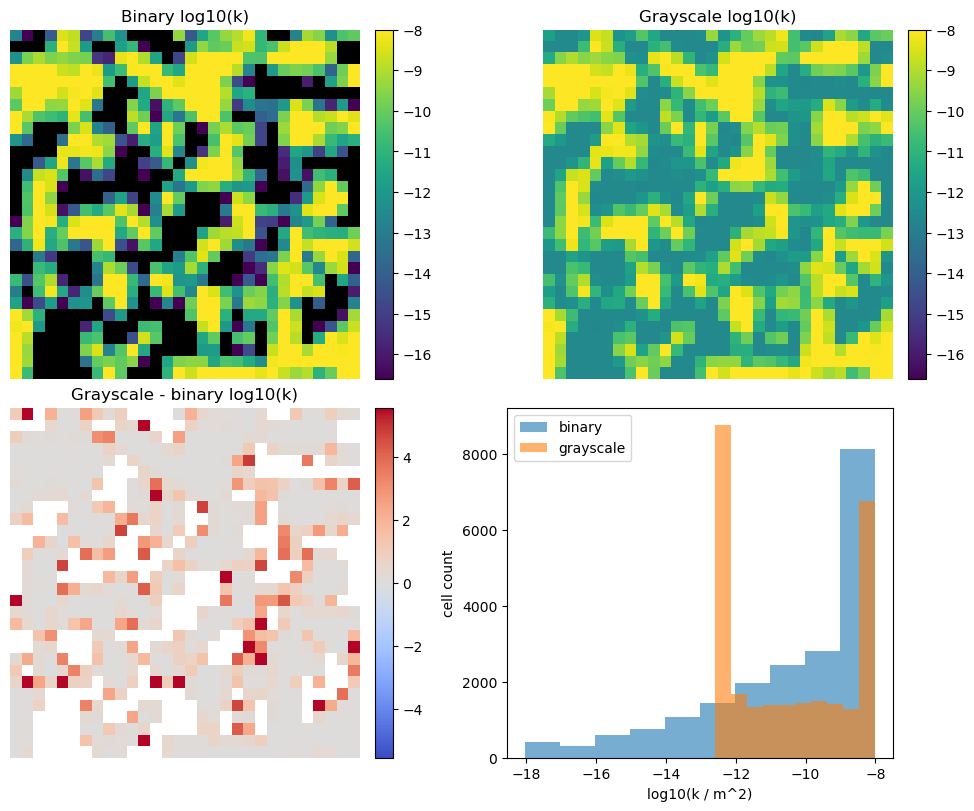

In [7]:


def _log10_positive(values: np.ndarray) -> np.ndarray:
    log_values = np.full(values.shape, np.nan, dtype=float)
    positive = np.isfinite(values) & (values > 0.0)
    log_values[positive] = np.log10(values[positive])
    return log_values


binary_log_k = _log10_positive(binary_permeability.values)
grayscale_log_k = _log10_positive(grayscale_permeability.values)
mid_cell = binary_porosity.shape[0] // 2
finite_log_k = np.concatenate(
    [
        binary_log_k[np.isfinite(binary_log_k)],
        grayscale_log_k[np.isfinite(grayscale_log_k)],
    ]
)
log_k_min, log_k_max = np.percentile(finite_log_k, [1.0, 99.0])

k_cmap = plt.get_cmap("viridis").copy()
k_cmap.set_bad(color="black")

fig_k, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

im = axes[0, 0].imshow(
    binary_log_k[mid_cell],
    vmin=log_k_min,
    vmax=log_k_max,
    cmap=k_cmap,
    origin="lower",
)
axes[0, 0].set_title("Binary log10(k)")
axes[0, 0].set_axis_off()
fig_k.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

im = axes[0, 1].imshow(
    grayscale_log_k[mid_cell],
    vmin=log_k_min,
    vmax=log_k_max,
    cmap=k_cmap,
    origin="lower",
)
axes[0, 1].set_title("Grayscale log10(k)")
axes[0, 1].set_axis_off()
fig_k.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

log_k_delta = grayscale_log_k - binary_log_k
delta_abs = np.nanpercentile(np.abs(log_k_delta), 99.0)
im = axes[1, 0].imshow(
    log_k_delta[mid_cell],
    vmin=-delta_abs,
    vmax=delta_abs,
    cmap="coolwarm",
    origin="lower",
)
axes[1, 0].set_title("Grayscale - binary log10(k)")
axes[1, 0].set_axis_off()
fig_k.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].hist(binary_log_k[np.isfinite(binary_log_k)], alpha=0.6, label="binary")
axes[1, 1].hist(
    grayscale_log_k[np.isfinite(grayscale_log_k)],
    alpha=0.6,
    label="grayscale",
)
axes[1, 1].set_xlabel("log10(k / m^2)")
axes[1, 1].set_ylabel("cell count")
axes[1, 1].legend()

permeability_figure_path = output_dir / "synthetic_kozeny_carman_permeability_maps.png"
fig_k.savefig(permeability_figure_path, dpi=180)
permeability_figure_path

## Visual comparison

The maps have `300^3` input voxels and `30^3` porosity cells. The middle
slices below show the original binary/grayscale inputs and the coarser local
porosity fields on the same physical section.

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/33_mwe_synthetic_porosity_maps/synthetic_porosity_maps.png')

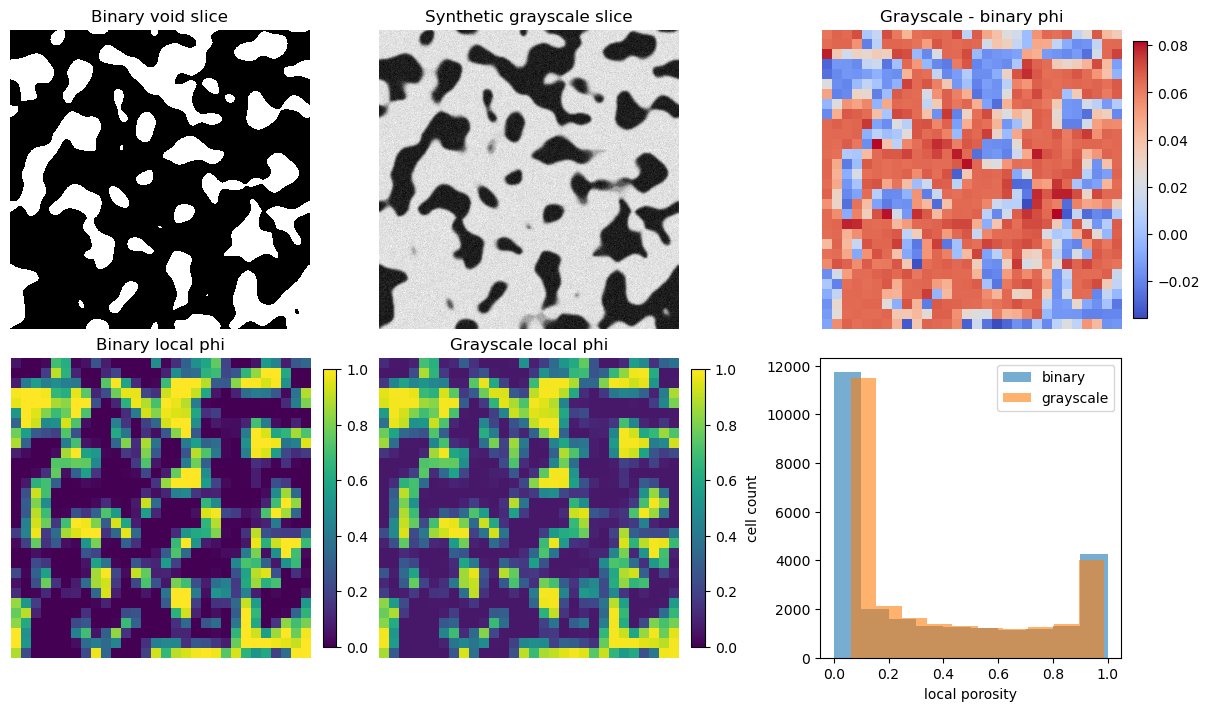

In [8]:
mid_voxel = shape[0] // 2
mid_cell = binary_porosity.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

axes[0, 0].imshow(binary_void[mid_voxel], cmap="gray", origin="lower")
axes[0, 0].set_title("Binary void slice")
axes[0, 0].set_axis_off()

axes[0, 1].imshow(grayscale[mid_voxel], cmap="gray", origin="lower")
axes[0, 1].set_title("Synthetic grayscale slice")
axes[0, 1].set_axis_off()

diff = grayscale_porosity.values - binary_porosity.values
im = axes[0, 2].imshow(diff[mid_cell], cmap="coolwarm", origin="lower")
axes[0, 2].set_title("Grayscale - binary phi")
axes[0, 2].set_axis_off()
fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

im = axes[1, 0].imshow(
    binary_porosity.values[mid_cell], vmin=0.0, vmax=1.0, origin="lower"
)
axes[1, 0].set_title("Binary local phi")
axes[1, 0].set_axis_off()
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

im = axes[1, 1].imshow(
    grayscale_porosity.values[mid_cell],
    vmin=0.0,
    vmax=1.0,
    origin="lower",
)
axes[1, 1].set_title("Grayscale local phi")
axes[1, 1].set_axis_off()
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

axes[1, 2].hist(binary_porosity.values.ravel(), alpha=0.6, label="binary")
axes[1, 2].hist(grayscale_porosity.values.ravel(), alpha=0.6, label="grayscale")
axes[1, 2].set_xlabel("local porosity")
axes[1, 2].set_ylabel("cell count")
axes[1, 2].legend()

figure_path = output_dir / "synthetic_porosity_maps.png"
fig.savefig(figure_path, dpi=180)
figure_path

## Export for downstream continuum workflows

The current export is a compact HDF5 file with the cell-average porosity array
and metadata. This is not yet a solver-specific FEM export, but it gives
stable field files that can be converted to OpenFOAM, XDMF, VTK, or another
mesh/cell ordering once that target is chosen.

In [9]:
binary_h5 = output_dir / "binary_porosity_map.h5"
grayscale_h5 = output_dir / "grayscale_porosity_map.h5"
binary_k_h5 = output_dir / "binary_kozeny_carman_permeability_map.h5"
grayscale_k_h5 = output_dir / "grayscale_kozeny_carman_permeability_map.h5"

save_porosity_map_hdf5(binary_porosity, binary_h5)
save_porosity_map_hdf5(grayscale_porosity, grayscale_h5)
save_permeability_map_hdf5(binary_permeability, binary_k_h5)
save_permeability_map_hdf5(grayscale_permeability, grayscale_k_h5)

binary_loaded = load_porosity_map_hdf5(binary_h5)
grayscale_loaded = load_porosity_map_hdf5(grayscale_h5)
binary_k_loaded = load_permeability_map_hdf5(binary_k_h5)
grayscale_k_loaded = load_permeability_map_hdf5(grayscale_k_h5)

assert np.allclose(binary_loaded.values, binary_porosity.values)
assert np.allclose(grayscale_loaded.values, grayscale_porosity.values)
assert np.allclose(binary_k_loaded.values, binary_permeability.values)
assert np.allclose(grayscale_k_loaded.values, grayscale_permeability.values)
assert binary_loaded.cell_size == binary_porosity.cell_size
assert grayscale_loaded.cell_size == grayscale_porosity.cell_size
assert binary_k_loaded.cell_size == binary_permeability.cell_size
assert grayscale_k_loaded.cell_size == grayscale_permeability.cell_size

exports = pd.DataFrame(
    [
        {
            "artifact": "binary porosity map",
            "path": str(binary_h5.relative_to(project_root)),
            "mean_phi": binary_loaded.mean_porosity,
        },
        {
            "artifact": "grayscale porosity map",
            "path": str(grayscale_h5.relative_to(project_root)),
            "mean_phi": grayscale_loaded.mean_porosity,
        },
        {
            "artifact": "binary Kozeny-Carman permeability map",
            "path": str(binary_k_h5.relative_to(project_root)),
            "mean_phi": np.nan,
        },
        {
            "artifact": "grayscale Kozeny-Carman permeability map",
            "path": str(grayscale_k_h5.relative_to(project_root)),
            "mean_phi": np.nan,
        },
        {
            "artifact": "comparison figure",
            "path": str(figure_path.relative_to(project_root)),
            "mean_phi": np.nan,
        },
        {
            "artifact": "permeability comparison figure",
            "path": str(permeability_figure_path.relative_to(project_root)),
            "mean_phi": np.nan,
        },
    ]
)
display(exports)

,artifact,path,mean_phi
0,binary porosity map,notebooks/outputs/33_mwe_synthetic_porosity_ma...,0.350000
1,grayscale porosity map,notebooks/outputs/33_mwe_synthetic_porosity_ma...,0.386772
2,binary Kozeny-Carman permeability map,notebooks/outputs/33_mwe_synthetic_porosity_ma...,NaN
3,grayscale Kozeny-Carman permeability map,notebooks/outputs/33_mwe_synthetic_porosity_ma...,NaN
4,comparison figure,notebooks/outputs/33_mwe_synthetic_porosity_ma...,NaN
5,permeability comparison figure,notebooks/outputs/33_mwe_synthetic_porosity_ma...,NaN


## Interpretation notes

The binary and grayscale means are close, but they are not expected to be
identical. The grayscale route includes blur, noise, clipping, and a nonzero
background porosity assigned to the solid calibration endpoint. With real
micro-CT data, the scientific checks should include scanner preprocessing,
support/crop handling, calibration endpoints, laboratory porosity, and whether
unresolved microporosity is represented by a background porosity value.